# **APE_04_Momentos — Esperanza Matemática, Varianza y Análisis de Tendencia Central**
# 🧠 **Integrantes — Grupo D:**

*   Noelia Bustan
*   Alison Tapia
*   Christopher Pineda
*   Elian Jimenez
*   Yimmy Angulo
-----------------

## 📝 **Introducción**

El presente cuaderno desarrolla la **Guía de Actividades Práctico-Experimentales Nro. 004** de la asignatura *Teoría de la Distribución y Probabilidad*, cuyo objetivo es calcular teórica y computacionalmente la **esperanza matemática** ($E[X]$) y la **varianza** ($V[X]$) de variables aleatorias discretas y continuas, y aplicar el análisis de tendencia central y dispersión sobre el dataset regional del Proyecto Integrador (casos de dengue del MSP, provincia de **Loja**, periodo 2021 - 2025).

Se desarrollan las cuatro tareas solicitadas:

1. **Tarea 1:** validación de la clase invertida (Semana 4) mediante la simulación de una variable de Bernoulli.
2. **Tarea 2:** cálculo teórico de momentos ($E[X]$, $V[X]$) de una variable discreta (Binomial) y una continua (Normal) usando `scipy.stats`.
3. **Tarea 3 (Hito del Proyecto):** cálculo de la media y varianza muestral (estimador insesgado, $ddof=1$) sobre dos variables cuantitativas del dataset regional de Loja.
4. **Tarea 4 (ABI):** justificación estadística del parámetro `ddof=1` y generación de espacios muestrales con la librería `itertools`.

Finalmente, se responden las **preguntas de control** propuestas en la guía.

---
# **🛠️ Tarea 1: Validación de Clase Invertida (Semana 4) — Variable de Bernoulli**

### Contexto

Como modificación personal de la variable de Bernoulli trabajada en la clase invertida, se define el experimento:

> *"Un paciente diagnosticado con dengue en la provincia de Loja es de sexo masculino."*

$$
X = \begin{cases} 1 & \text{si el paciente es de sexo masculino} \\ 0 & \text{si el paciente es de sexo femenino} \end{cases}
$$

La función de masa de probabilidad (PMF) de una variable de Bernoulli es:

$$
P(X=x) = p^{x}(1-p)^{1-x}, \qquad x \in \{0,1\}
$$

con momentos teóricos $E[X] = p$ y $V[X] = p(1-p)$.

El parámetro $p$ se estima de forma **empírica** a partir del propio dataset regional (proporción real de pacientes masculinos entre los casos de dengue registrados en Loja).

Proporción empírica de pacientes masculinos en Loja (p): 0.5000

--- Momentos Teóricos vs. Simulados ---
E[X] teórico = 0.5000   |   E[X] simulado (n=1000) = 0.4970
V[X] teórico = 0.2500   |   V[X] simulado (n=1000) = 0.2502


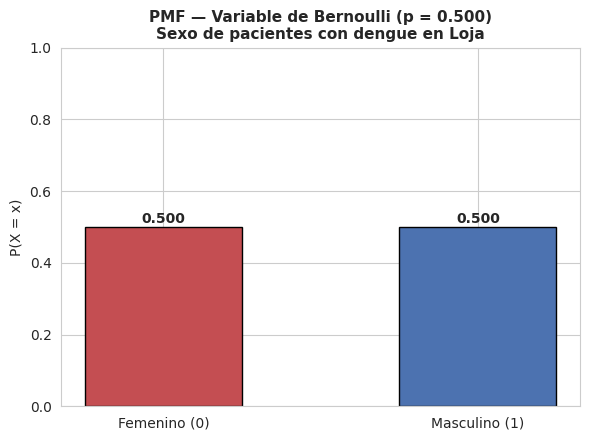

In [1]:
# ==========================================================
# TAREA 1 — VARIABLE DE BERNOULLI (Clase Invertida, Semana 4)
# ==========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import bernoulli

sns.set_style("whitegrid")

# ----------------------------------------------------------
# Estimación empírica de p a partir del dataset regional
# ----------------------------------------------------------
archivo = "Datos_Dengue_MSP_Ene2021_Ago2025.xlsx"
df_casos = pd.read_excel(archivo, sheet_name="DCSA_DG_2021_2025")
df_casos.columns = [c.strip() for c in df_casos.columns]

df_loja_casos = df_casos[df_casos["Prov Domic"].astype(str).str.contains("LOJA", case=False, na=False)].copy()

p_empirico = (df_loja_casos["Sexo"].astype(str).str.upper() == "MASCULINO").mean()
print(f"Proporción empírica de pacientes masculinos en Loja (p): {p_empirico:.4f}")

# ----------------------------------------------------------
# Variable de Bernoulli (scipy.stats) y simulación
# ----------------------------------------------------------
var_bernoulli = bernoulli(p_empirico)

esperanza_teo, varianza_teo = var_bernoulli.stats(moments="mv")

np.random.seed(42)
n_simulaciones = 1000
muestra_sim = var_bernoulli.rvs(size=n_simulaciones)

esperanza_sim = muestra_sim.mean()
varianza_sim = muestra_sim.var(ddof=1)

print("\n--- Momentos Teóricos vs. Simulados ---")
print(f"E[X] teórico = {esperanza_teo:.4f}   |   E[X] simulado (n={n_simulaciones}) = {esperanza_sim:.4f}")
print(f"V[X] teórico = {varianza_teo:.4f}   |   V[X] simulado (n={n_simulaciones}) = {varianza_sim:.4f}")

# ----------------------------------------------------------
# Función de Masa de Probabilidad (PMF)
# ----------------------------------------------------------
valores_x = [0, 1]
pmf_valores = var_bernoulli.pmf(valores_x)

plt.figure(figsize=(6, 4.5))
plt.bar(valores_x, pmf_valores, color=["#C44E52", "#4C72B0"], width=0.5, edgecolor="black")
for x, y in zip(valores_x, pmf_valores):
    plt.text(x, y + 0.01, f"{y:.3f}", ha="center", fontweight="bold")
plt.xticks(valores_x, ["Femenino (0)", "Masculino (1)"])
plt.ylim(0, 1)
plt.ylabel("P(X = x)")
plt.title(f"PMF — Variable de Bernoulli (p = {p_empirico:.3f})\nSexo de pacientes con dengue en Loja", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


### **Interpretación**

La proporción empírica de pacientes masculinos entre los casos de dengue registrados en Loja es $p = 0.5000$ (175 de 350 casos), por lo que la variable de Bernoulli resulta perfectamente equilibrada. Los momentos simulados ($n=1000$ repeticiones) son consistentes con los momentos teóricos ($E[X]=p$, $V[X]=p(1-p)$), validando la comprensión del modelo trabajado en la clase invertida de la Semana 4.

---
# **🛠️ Tarea 2: Cálculo Teórico y Simulación de Esperanza Matemática ($E[X]$)**

Para una variable discreta, la esperanza se define como:

$$
E[X] = \sum_{x} x \cdot P(X=x)
$$

y para una variable continua:

$$
E[X] = \int_{-\infty}^{\infty} x \cdot f(x)\, dx
$$

Se calculan los momentos teóricos (media y varianza) de:

* Una **variable discreta**: distribución **Binomial** ($n=10$, $p=0.4$).
* Una **variable continua**: distribución **Normal** ($\mu=50$, $\sigma=5$).

utilizando la abstracción `.stats(moments='mv')` de `scipy.stats`, tal como lo indica la guía de la práctica.

In [2]:
# ==========================================================
# TAREA 2 — MOMENTOS TEÓRICOS CON SCIPY.STATS
# ==========================================================
from scipy.stats import binom, norm

# ----------------------------------------------------------
# 1. Variable Aleatoria Discreta (Distribución Binomial)
# ----------------------------------------------------------
n_ensayos, p_exito = 10, 0.4
var_discreta = binom(n_ensayos, p_exito)

# Cálculo de Momentos Teóricos (Mean, Variance)
esperanza_d, varianza_d = var_discreta.stats(moments='mv')
print(f"--- Variable Discreta (Binomial n={n_ensayos}, p={p_exito}) ---")
print(f"Esperanza E[X]: {esperanza_d}")
print(f"Varianza V[X]: {varianza_d}\n")

# ----------------------------------------------------------
# 2. Variable Aleatoria Continua (Distribución Normal)
# ----------------------------------------------------------
mu, sigma = 50, 5  # Media y Desviación Estándar
var_continua = norm(loc=mu, scale=sigma)

esperanza_c, varianza_c = var_continua.stats(moments='mv')
print(f"--- Variable Continua (Normal mu={mu}, sigma={sigma}) ---")
print(f"Esperanza E[X]: {esperanza_c}")
print(f"Varianza V[X]: {varianza_c}")


--- Variable Discreta (Binomial n=10, p=0.4) ---
Esperanza E[X]: 4.0
Varianza V[X]: 2.3999999999999995

--- Variable Continua (Normal mu=50, sigma=5) ---
Esperanza E[X]: 50.0
Varianza V[X]: 25.0


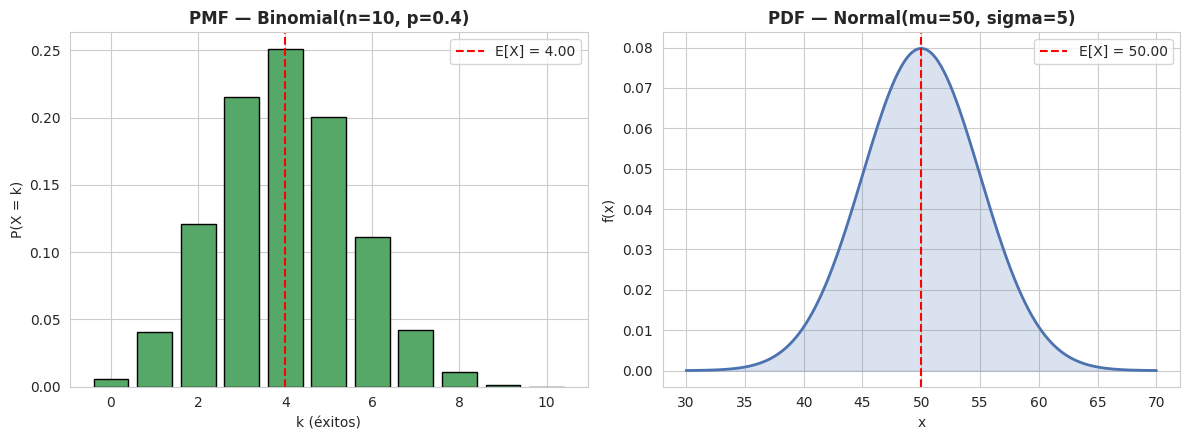

In [3]:
# ==========================================================
# VISUALIZACIÓN COMPLEMENTARIA: PMF (Binomial) y PDF (Normal)
# ==========================================================
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

# --- PMF de la Binomial ---
valores_k = np.arange(0, n_ensayos + 1)
pmf_binom = var_discreta.pmf(valores_k)
ejes[0].bar(valores_k, pmf_binom, color="#55A868", edgecolor="black")
ejes[0].axvline(esperanza_d, color="red", linestyle="--", label=f"E[X] = {esperanza_d:.2f}")
ejes[0].set_title(f"PMF — Binomial(n={n_ensayos}, p={p_exito})", fontweight="bold")
ejes[0].set_xlabel("k (éxitos)")
ejes[0].set_ylabel("P(X = k)")
ejes[0].legend()

# --- PDF de la Normal ---
x_vals = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 300)
pdf_norm = var_continua.pdf(x_vals)
ejes[1].plot(x_vals, pdf_norm, color="#4C72B0", linewidth=2)
ejes[1].fill_between(x_vals, pdf_norm, alpha=0.2, color="#4C72B0")
ejes[1].axvline(esperanza_c, color="red", linestyle="--", label=f"E[X] = {esperanza_c:.2f}")
ejes[1].set_title(f"PDF — Normal(mu={mu}, sigma={sigma})", fontweight="bold")
ejes[1].set_xlabel("x")
ejes[1].set_ylabel("f(x)")
ejes[1].legend()

plt.tight_layout()
plt.show()


### **Interpretación**

Para la variable discreta Binomial($n=10$, $p=0.4$), la esperanza teórica es $E[X] = np = 4.0$ y la varianza es $V[X] = np(1-p) = 2.4$, lo cual coincide exactamente con el resultado entregado por `scipy.stats`. Para la variable continua Normal($\mu=50$, $\sigma=5$), la esperanza coincide con el parámetro de localización ($E[X]=50$) y la varianza con $\sigma^2=25$. Esto confirma que la abstracción `.stats(moments='mv')` calcula correctamente los momentos teóricos definidos por la función de distribución, sin necesidad de resolver manualmente la sumatoria o la integral.

---
# **🛠️ Tarea 3 (Hito del Proyecto): Análisis de Tendencia Central y Dispersión**

Se aplican los conceptos teóricos al **dataset regional real** (casos de dengue del MSP en la provincia de Loja). Se identifican **dos variables cuantitativas clave**:

1. **Edad** de los pacientes con dengue (hoja `DCSA_DG_2021_2025`, registro individual por caso).
2. **Total** de casos reportados por semana epidemiológica y parroquia (hoja `DSSA_2021_2024`, registro de vigilancia semanal agregada).

Se calcula la **media muestral** ($\bar{x}$) y la **varianza muestral insesgada** ($s^2$), donde la suma de cuadrados se divide por $n-1$:

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i \qquad \qquad s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2
$$

 ANÁLISIS DEL DATASET REGIONAL — PROVINCIA DE LOJA 

Variable 1: Edad del paciente (n = 350)
  Media Muestral (Estimador de E[X])   : 29.15 años
  Varianza Muestral (Estimador de V[X]): 415.16

Variable 2: Total de casos por registro semanal (n = 697)
  Media Muestral (Estimador de E[X])   : 3.71 casos
  Varianza Muestral (Estimador de V[X]): 36.28


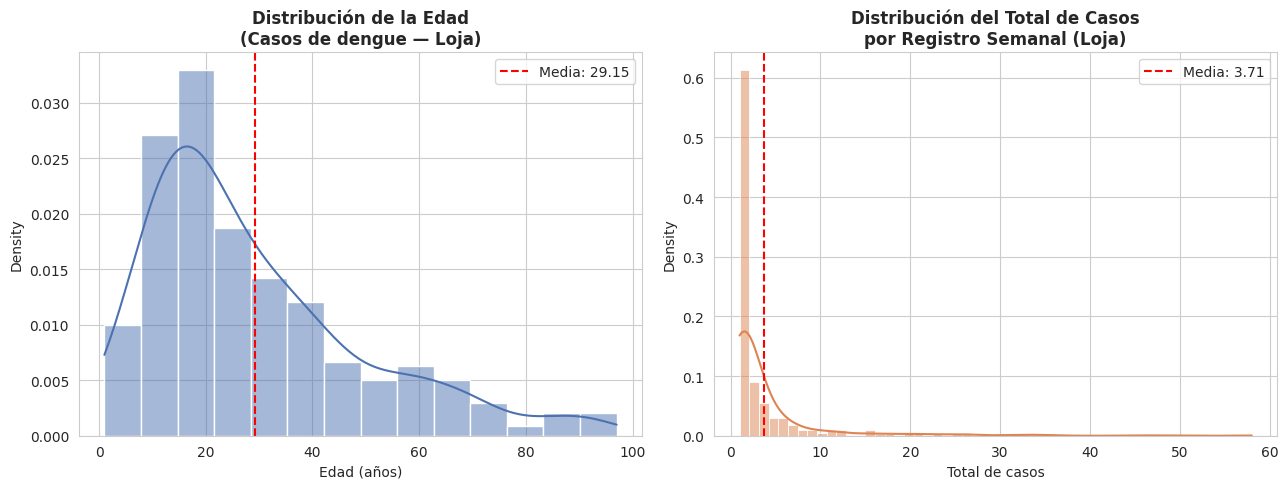

In [4]:
# ==========================================================
# TAREA 3 — HITO DEL PROYECTO: TENDENCIA CENTRAL Y DISPERSIÓN
# (Dataset regional real: casos de dengue MSP - Provincia de Loja)
# ==========================================================

# ----------------------------------------------------------
# Carga de datos reales del proyecto integrador
# ----------------------------------------------------------
df_semanal = pd.read_excel(archivo, sheet_name="DSSA_2021_2024")
df_semanal.columns = [c.strip() for c in df_semanal.columns]

df_loja_semanal = df_semanal[df_semanal["Provincia"].astype(str).str.contains("LOJA", case=False, na=False)].copy()

# Limpieza de la variable Edad (registro individual, ya cargado como df_loja_casos en la Tarea 1)
df_loja_casos["Edad"] = pd.to_numeric(df_loja_casos["Edad"], errors="coerce")
df_loja_casos = df_loja_casos.dropna(subset=["Edad"])

# ----------------------------------------------------------
# VARIABLE 1: Edad de los pacientes (registro individual)
# ----------------------------------------------------------
media_edad = df_loja_casos["Edad"].mean()
varianza_edad = df_loja_casos["Edad"].var(ddof=1)  # ddof=1 -> estimador insesgado

# ----------------------------------------------------------
# VARIABLE 2: Total de casos por semana epidemiológica (registro agregado)
# ----------------------------------------------------------
media_total = df_loja_semanal["Total"].mean()
varianza_total = df_loja_semanal["Total"].var(ddof=1)  # ddof=1 -> estimador insesgado

print("=" * 65)
print(" ANÁLISIS DEL DATASET REGIONAL — PROVINCIA DE LOJA ")
print("=" * 65)

print("\nVariable 1: Edad del paciente (n = {})".format(len(df_loja_casos)))
print(f"  Media Muestral (Estimador de E[X])   : {media_edad:.2f} años")
print(f"  Varianza Muestral (Estimador de V[X]): {varianza_edad:.2f}")

print("\nVariable 2: Total de casos por registro semanal (n = {})".format(len(df_loja_semanal)))
print(f"  Media Muestral (Estimador de E[X])   : {media_total:.2f} casos")
print(f"  Varianza Muestral (Estimador de V[X]): {varianza_total:.2f}")
print("=" * 65)

# ----------------------------------------------------------
# Visualización para el Hito del Proyecto
# ----------------------------------------------------------
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df_loja_casos["Edad"], kde=True, color="#4C72B0", stat="density", ax=ejes[0])
ejes[0].axvline(media_edad, color="red", linestyle="--", label=f"Media: {media_edad:.2f}")
ejes[0].set_title("Distribución de la Edad\n(Casos de dengue — Loja)", fontweight="bold")
ejes[0].set_xlabel("Edad (años)")
ejes[0].legend()

sns.histplot(df_loja_semanal["Total"], kde=True, color="#DD8452", stat="density", ax=ejes[1])
ejes[1].axvline(media_total, color="red", linestyle="--", label=f"Media: {media_total:.2f}")
ejes[1].set_title("Distribución del Total de Casos\npor Registro Semanal (Loja)", fontweight="bold")
ejes[1].set_xlabel("Total de casos")
ejes[1].legend()

plt.tight_layout()
plt.show()


### **Interpretación**

**Edad de los pacientes:** la media muestral es de **29.15 años**, con una varianza muestral de **415.16**, lo que equivale a una desviación estándar de aproximadamente 20.4 años. Esta dispersión relativamente alta indica que el dengue afecta a un rango etario muy amplio en Loja (desde menores de 1 año hasta adultos mayores), por lo que la media por sí sola no es un buen predictor puntual del perfil etario típico.

**Total de casos por registro semanal:** la media muestral es de **3.71 casos** por registro (parroquia-semana), con una varianza de **36.28**, notablemente superior al valor de la media. Esta sobre-dispersión (varianza >> media) es característica de los conteos de enfermedades infecciosas, donde brotes puntuales generan semanas con picos de hasta 58 casos frente a una mediana de apenas 2 casos, evidenciando la presencia de valores atípicos (outliers) asociados a brotes epidémicos localizados.

---
# **🛠️ Tarea 4 (ABI): Documentación y Discusión Grupal**

### Justificación estadística del parámetro `ddof`

Según la documentación oficial de **Pandas** [2] y **NumPy**, el parámetro `ddof` (*Delta Degrees of Freedom*) determina el divisor utilizado en el cálculo de la varianza: el divisor efectivo es $n - ddof$.

* Con `ddof=0`, la varianza se calcula como $\frac{1}{n}\sum (x_i-\bar{x})^2$: éste es el **estimador de máxima verosimilitud**, correcto únicamente cuando se dispone de **toda la población** y no de una muestra.
* Con `ddof=1`, la varianza se calcula como $\frac{1}{n-1}\sum (x_i-\bar{x})^2$: éste es el **estimador insesgado** de la varianza poblacional a partir de una **muestra**.

La razón matemática es que la media muestral $\bar{x}$ ya "consume" un grado de libertad al ser estimada a partir de los mismos datos utilizados para calcular la dispersión (se pierde un grado de libertad porque $\sum(x_i - \bar{x}) = 0$ por construcción). Dividir por $n$ en lugar de $n-1$ produce un estimador **sesgado hacia abajo** (subestima sistemáticamente la varianza poblacional real). Por ello, dado que el dataset regional de Loja utilizado en la Tarea 3 constituye una **muestra** de la población total de casos de dengue (no el universo completo de todos los casos posibles), se utiliza `ddof=1` para obtener un estimador insesgado de $V[X]$.

In [5]:
# ==========================================================
# TAREA 4 — ABI: GENERACIÓN DE ESPACIOS MUESTRALES CON ITERTOOLS
# ==========================================================
import itertools

# ----------------------------------------------------------
# Ejemplo 1: Espacio muestral de un resultado diagnóstico
# repetido en 3 pacientes consecutivos (Positivo / Negativo)
# ----------------------------------------------------------
resultados_posibles = ["Positivo", "Negativo"]
espacio_muestral_3 = list(itertools.product(resultados_posibles, repeat=3))

print("Espacio muestral: resultado diagnóstico de 3 pacientes consecutivos")
print(f"Número de eventos elementales: {len(espacio_muestral_3)}")
for evento in espacio_muestral_3:
    print("  ", evento)

# ----------------------------------------------------------
# Ejemplo 2: Combinaciones posibles al seleccionar 2 cantones
# de una muestra de 5 sectores de Loja para un estudio focalizado
# ----------------------------------------------------------
cantones_muestra = ["Loja", "Macará", "Catamayo", "Zapotillo", "Paltas"]
combinaciones_cantones = list(itertools.combinations(cantones_muestra, 2))

print(f"\nEspacio muestral: selección de 2 cantones de {len(cantones_muestra)} disponibles")
print(f"Número de combinaciones posibles: {len(combinaciones_cantones)}")
for combinacion in combinaciones_cantones:
    print("  ", combinacion)

# ----------------------------------------------------------
# Probabilidad clásica: al menos un resultado "Positivo"
# entre los 3 pacientes (enfoque clásico de probabilidad)
# ----------------------------------------------------------
eventos_favorables = [e for e in espacio_muestral_3 if "Positivo" in e]
prob_al_menos_un_positivo = len(eventos_favorables) / len(espacio_muestral_3)
print(f"\nP(al menos 1 diagnóstico Positivo en 3 pacientes) = {prob_al_menos_un_positivo:.4f}")


Espacio muestral: resultado diagnóstico de 3 pacientes consecutivos
Número de eventos elementales: 8
   ('Positivo', 'Positivo', 'Positivo')
   ('Positivo', 'Positivo', 'Negativo')
   ('Positivo', 'Negativo', 'Positivo')
   ('Positivo', 'Negativo', 'Negativo')
   ('Negativo', 'Positivo', 'Positivo')
   ('Negativo', 'Positivo', 'Negativo')
   ('Negativo', 'Negativo', 'Positivo')
   ('Negativo', 'Negativo', 'Negativo')

Espacio muestral: selección de 2 cantones de 5 disponibles
Número de combinaciones posibles: 10
   ('Loja', 'Macará')
   ('Loja', 'Catamayo')
   ('Loja', 'Zapotillo')
   ('Loja', 'Paltas')
   ('Macará', 'Catamayo')
   ('Macará', 'Zapotillo')
   ('Macará', 'Paltas')
   ('Catamayo', 'Zapotillo')
   ('Catamayo', 'Paltas')
   ('Zapotillo', 'Paltas')

P(al menos 1 diagnóstico Positivo en 3 pacientes) = 0.8750


**Metodología activa empleada:** ABP (Aprendizaje Basado en Problemas), según el enfoque PID-2025. La generación de espacios muestrales mediante `itertools.product` e `itertools.combinations` permite enumerar de forma exhaustiva y sistemática todos los eventos elementales de un experimento aleatorio, sustentando el cálculo de probabilidades bajo el **enfoque clásico** (razón entre casos favorables y casos posibles), en contraste con el **enfoque empírico** utilizado en la Tarea 1 (proporción observada en el dataset real).

---
# **❓ Preguntas de Control**

**1. ¿Cuál es la diferencia matemática y conceptual entre la esperanza matemática teórica calculada a partir de un modelo de probabilidad (ej. `binom.stats()`) y la media muestral calculada de un DataFrame de pandas?**

La esperanza teórica $E[X]=\sum x \cdot P(X=x)$ es un **parámetro poblacional**, un valor fijo y exacto que se deriva analíticamente de un modelo probabilístico asumido (por ejemplo, la Binomial con parámetros conocidos $n$ y $p$). La media muestral $\bar{x}=\frac{1}{n}\sum x_i$, en cambio, es un **estadístico**: una variable aleatoria calculada a partir de datos observados, que varía de una muestra a otra y que se utiliza como **estimador** del verdadero valor poblacional (que en la práctica casi nunca se conoce con exactitud).

**2. Demuestre teóricamente, utilizando las propiedades de la esperanza, por qué la varianza se puede reescribir como $V[X]=E[X^2]-(E[X])^2$.**

Partiendo de la definición $V[X] = E\big[(X-E[X])^2\big]$, y sea $\mu = E[X]$:

$$
V[X] = E[(X-\mu)^2] = E[X^2 - 2\mu X + \mu^2]
$$

Por linealidad de la esperanza:

$$
V[X] = E[X^2] - 2\mu E[X] + \mu^2 = E[X^2] - 2\mu^2 + \mu^2 = E[X^2] - \mu^2
$$

Sustituyendo $\mu = E[X]$ se obtiene:

$$
V[X] = E[X^2] - (E[X])^2
$$

**3. Si la varianza calculada en su variable regional es inusualmente alta, ¿qué implicaciones prácticas tiene esto sobre la confiabilidad de la media como predictor del comportamiento de esos datos en la región de Loja?**

Como se observó en la Tarea 3 con la variable "Total de casos semanales" ($s^2 = 36.28$ frente a una media de apenas $3.71$), una varianza inusualmente alta en relación con la media indica una **dispersión considerable y presencia de valores extremos** (brotes epidémicos puntuales). En estos casos, la media deja de ser un buen resumen del comportamiento "típico" de los datos: la mayoría de los registros semanales presentan pocos casos, pero unos pocos registros con brotes elevan artificialmente el promedio. Para la toma de decisiones en salud pública, esto implica que la media debe complementarse con medidas de dispersión (varianza, desviación estándar) y con la mediana o los percentiles, evitando basar las políticas de vigilancia únicamente en el promedio.

**4. Revise el parámetro `ddof` de la función `var()` en Pandas. ¿Qué ocurre con el estimador de la varianza si establecemos `ddof=0` y en qué escenario específico de población poblacional esto sería matemáticamente correcto?**

Con `ddof=0`, el divisor pasa de $n-1$ a $n$, por lo que el estimador resultante ($\frac{1}{n}\sum(x_i-\bar{x})^2$) es **ligeramente menor** que el estimador insesgado (sesgado hacia abajo). Este divisor sería matemáticamente correcto únicamente si los datos disponibles constituyeran la **población completa** de interés (por ejemplo, si el dataset contuviera absolutamente todos los casos de dengue ocurridos en Loja, sin excepción, y no una muestra o un subconjunto reportado). En ese escenario, ya no se estaría estimando un parámetro poblacional a partir de una muestra, sino calculando directamente el parámetro poblacional, por lo que no habría pérdida de un grado de libertad.

**5. Observe el histograma generado en la Tarea 3. ¿De qué manera el cálculo combinado de la esperanza matemática (media) y la varianza apoyan en la identificación estadística de valores atípicos (outliers) para la posterior limpieza de su Proyecto Integrador?**

El histograma del "Total de casos semanales" muestra una distribución fuertemente asimétrica hacia la derecha, con la mayoría de los registros concentrados en valores bajos (1 a 3 casos) y una cola larga hacia registros con hasta 58 casos. Al combinar la media ($\bar{x}=3.71$) con la varianza ($s^2=36.28$, $s\approx 6.02$), es posible construir un criterio cuantitativo de detección de atípicos (por ejemplo, marcar como outlier todo registro que exceda $\bar{x} + 3s \approx 21.8$ casos). Este criterio, basado en los dos primeros momentos estadísticos, permite distinguir entre la variabilidad epidemiológica normal (fluctuación semana a semana) y los brotes anómalos que ameritan una revisión específica antes de continuar con la limpieza y modelado del dataset en el Proyecto Integrador.

---
# 📚 **Bibliografía**

[1] R. E. Walpole, R. H. Myers, S. L. Myers, y K. Ye, *Probabilidad y estadística para ingeniería y ciencias*, 9na ed. Pearson Educación, 2012.

[2] W. McKinney, *Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython*, 3ra ed. O'Reilly Media, 2022.

[3] SciPy Developers, "scipy.stats Documentation," *SciPy.org*, 2024. [Online]. Disponible: https://docs.scipy.org/doc/scipy/reference/stats.html. [Accedido: 18-Mar-2026].

[4] Python Software Foundation, "itertools — Functions creating iterators for efficient looping," *Python 3 Documentation*, 2024. [Online]. Disponible: https://docs.python.org/3/library/itertools.html. [Accedido: 03-Jul-2026].